# Why did the fiscal decision tree fail to beat persistence?
This diagnostic follow-up preserves the original experiment. The only source dataset is **NSW Data Panel.csv**; the original notebook and its saved predictions are used only to reproduce and verify the earlier analysis. No external observations are added.

We distinguish directly observed failure mechanisms from plausible data limitations. These follow-up comparisons reuse already inspected test years: they are exploratory diagnostics, **not independent confirmation** or a search for the best model. Operating ratio remains primary; cash cover and maintenance remain separate secondary outcomes.

Questions: (1) Does the result reproduce? (2) Is there a training-to-future generalisation gap? (3) Do disaster inputs change predictions? (4) Does the tree improve or harm the persistence prediction? (5) Are errors concentrated in a few councils or disaster groups? (6) Can the same shallow tree predict changes instead of levels?

In [1]:
from pathlib import Path
import hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = Path.cwd()
SOURCE = ROOT / 'NSW Data Panel.csv'
assert SOURCE.exists(), 'Run this notebook with AUSSEF as the working directory.'
OUT = ROOT / 'outputs' / 'decision_tree_diagnostics'
OUT.mkdir(parents=True, exist_ok=True)
SOURCE_HASH = hashlib.sha256(SOURCE.read_bytes()).hexdigest()
SEED, MAX_DEPTH, MIN_LEAF, MIN_TRAIN = 42, 3, 20, 100
TARGETS = {'operating_ratio_pct': 'percentage points',
           'cash_cover_months': 'months',
           'maintenance_ratio_pct': 'percentage points'}
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_colwidth', 95)
raw = pd.read_csv(SOURCE)
assert not raw.duplicated(['council_key', 'year_start']).any()
assert raw[['council_key', 'year_start']].notna().all().all()
assert (raw.financial_year == raw.year_start.map(lambda y: f'{y}-{str(y+1)[-2:]}')).all()
print(f'{len(raw):,} rows; {len(raw.columns)} columns; {raw.council_key.nunique()} council keys')
print('Financial years:', ', '.join(sorted(raw.financial_year.unique())))
print('Source SHA-256:', SOURCE_HASH)
ORIGINAL = ROOT / 'outputs' / 'decision_tree'
assert SOURCE_HASH == json.loads((ORIGINAL/'run_manifest.json').read_text())['sha256']

1,024 rows; 54 columns; 128 council keys
Financial years: 2017-18, 2018-19, 2019-20, 2020-21, 2021-22, 2022-23, 2023-24, 2024-25
Source SHA-256: d96fd82b53295460f5b7baacd7a10124d1b061826ad70f6148a6728d71d77bab


## 1. Reconstruct the original sample without changing the design
Use the same exact-year joins, boundary exclusions, target-quality rules and persistence-observed cohort. The forecast uses fiscal information from t−1 to predict t+1: there is a **two-financial-year separation** between the baseline measurement and the outcome. Training outcome years must be before the test disaster year. This deliberately conservative embargo leaves only one training-label year in the first fold.

The code below copies the original alignment logic. We do not silently substitute t fiscal data or change the outcome horizon.

In [2]:
prior_cols = ['operating_ratio_pct','cash_cover_months','current_ratio','own_source_pct','debt_service_cover','maintenance_ratio_pct','population','road_km']
exposure_cols = ['fesm_burned_ha','bushfire_declared_event_count','flood_declared_event_count']
features = [c+'__prior' for c in prior_cols] + [c+'__event' for c in exposure_cols]
prior = raw[['council_key','year_start'] + prior_cols + ['boundary_change_flag','outcome_quality_eligible']].copy()
prior.loc[~prior.outcome_quality_eligible, 'maintenance_ratio_pct'] = np.nan
prior = prior.rename(columns={c:c+'__prior' for c in prior if c != 'council_key'})
prior['event_year'] = prior.year_start__prior + 1
future = raw[['council_key','year_start'] + list(TARGETS) + ['boundary_change_flag','outcome_quality_eligible']].copy()
future = future.rename(columns={c:c+'__future' for c in future if c != 'council_key'})
future['event_year'] = future.year_start__future - 1
panel = raw[['council_key','year_start'] + exposure_cols + ['boundary_change_flag']].rename(
    columns={'year_start':'event_year', **{c:c+'__event' for c in exposure_cols}})
panel = panel.merge(prior, on=['council_key','event_year'], how='left', validate='one_to_one')
panel = panel.merge(future, on=['council_key','event_year'], how='left', validate='one_to_one')
panel['target_year'] = panel.event_year + 1
panel['prior_year'] = panel.event_year - 1
assert set(features).issubset(panel.columns)
assert all(c.endswith(('__prior','__event')) for c in features)
assert (panel.loc[panel.year_start__prior.notna(), 'year_start__prior'] == panel.loc[panel.year_start__prior.notna(), 'prior_year']).all()
assert (panel.loc[panel.year_start__future.notna(), 'year_start__future'] == panel.loc[panel.year_start__future.notna(), 'target_year']).all()

# One mutually exclusive first-failure reason per target and row.
cohorts = {}
for target in TARGETS:
    d = panel.copy()
    checks = [
        ('no_exact_prior_year', d.year_start__prior.isna()),
        ('no_exact_future_year', d.year_start__future.isna()),
        ('boundary_flag', d.boundary_change_flag | d.boundary_change_flag__prior.eq(True) | d.boundary_change_flag__future.eq(True)),
        ('missing_target', ~np.isfinite(d[target+'__future'])),
    ]
    if target == 'maintenance_ratio_pct':
        checks.append(('target_maintenance_quality', ~d.outcome_quality_eligible__future.eq(True)))
    checks.append(('missing_or_ineligible_persistence', ~np.isfinite(d[target+'__prior'])))
    d['exclusion_reason'] = np.select([m for _,m in checks], [r for r,_ in checks], default='eligible')
    d['eligible'] = d.exclusion_reason.eq('eligible')
    cohorts[target] = d
alignment_audit = pd.concat([d[['council_key','prior_year','event_year','target_year','exclusion_reason']].assign(target=t)
                             for t,d in cohorts.items()], ignore_index=True)
alignment_audit.to_csv(OUT/'row_eligibility.csv', index=False)
coverage = alignment_audit.groupby(['target','target_year','exclusion_reason']).size().rename('rows').reset_index()
coverage.to_csv(OUT/'alignment_exclusions_by_year.csv', index=False)
display(coverage.pivot_table(index=['target','target_year'], columns='exclusion_reason', values='rows', fill_value=0))

exclusion_reason                   boundary_flag  eligible  \
target                target_year                            
cash_cover_months     2018                   0.0       0.0   
                      2019                   4.0     121.0   
                      2020                   4.0     123.0   
                      2021                   4.0     124.0   
                      2022                   4.0     122.0   
                      2023                   4.0     124.0   
                      2024                   4.0       0.0   
                      2025                   0.0       0.0   
maintenance_ratio_pct 2018                   0.0       0.0   
                      2019                   4.0     119.0   
                      2020                   4.0     120.0   
                      2021                   4.0     122.0   
                      2022                   4.0     120.0   
                      2023                   4.0     122.0   
                      2024                   4.0     121.0   
                      2025                   0.0       0.0   
operating_ratio_pct   2018                   0.0       0.0   
                      2019                   4.0     121.0   
                      2020                   4.0     122.0   
                      2021                   4.0     124.0   
                      2022                   4.0     122.0   
                      2023                   4.0     124.0   
                      2024                   4.0       0.0   
                      2025                   0.0       0.0   

exclusion_reason                   missing_or_ineligible_persistence  \
target                target_year                                      
cash_cover_months     2018                                       0.0   
                      2019                                       3.0   
                      2020                                       0.0   
                      2021                                       0.0   
                      2022                                       1.0   
                      2023                                       0.0   
                      2024                                       0.0   
                      2025                                       0.0   
maintenance_ratio_pct 2018                                       0.0   
                      2019                                       4.0   
                      2020                                       1.0   
                      2021                                       0.0   
                      2022                                       2.0   
                      2023                                       1.0   
                      2024                                       2.0   
                      2025                                       0.0   
operating_ratio_pct   2018                                       0.0   
                      2019                                       3.0   
                      2020                                       1.0   
                      2021                                       0.0   
                      2022                                       1.0   
                      2023                                       0.0   
                      2024                                       0.0   
                      2025                                       0.0   

exclusion_reason                   missing_target  no_exact_future_year  \
target                target_year                                         
cash_cover_months     2018                    0.0                   0.0   
                      2019                    0.0                   0.0   
                      2020                    1.0                   0.0   
                      2021                    0.0                   0.0   
                      2022                    1.0               

## 2. Fixed, bounded diagnostic comparisons
Keep depth 3, minimum leaf size 20, seed 42 and training-fold-only median imputation throughout. No tuning, ensemble or random row split.

- **Full level tree:** reproduce the original model.
- **Fiscal-only level tree:** remove the three exposure inputs, changing nothing else.
- **Change tree:** predict t+1 minus t−1, then add the observed t−1 value back to obtain the fiscal-level forecast. A level tree must approximate each council's prior level with a few leaf averages; a change tree gives that baseline to every council exactly before estimating an adjustment.
- **Mean-change baseline:** add the training-average change to each council's t−1 value. Zero predicted change is exactly the original persistence baseline.

The change experiment can diagnose a representation problem, but it cannot establish a causal disaster effect. Its target differs from the original level fit and its results are post hoc.

In [3]:
def metrics(y, p):
    return dict(MAE=mean_absolute_error(y,p), RMSE=np.sqrt(mean_squared_error(y,p)),
                R2=r2_score(y,p,force_finite=False) if len(y)>1 and np.var(y)>0 else np.nan)

def make_tree():
    return Pipeline([('imputer',SimpleImputer(strategy='median')),
                     ('tree',DecisionTreeRegressor(max_depth=3,min_samples_leaf=20,random_state=42))])

records, fold_records, leaf_records, feature_records = [], [], [], []
for target,d in cohorts.items():
    for year in sorted(d.target_year.unique()):
        train=d[d.eligible & (d.target_year < year-1)]
        test=d[d.eligible & (d.target_year == year)]
        if len(train)<100 or len(test)<2: continue
        assert train.target_year.max() < test.event_year.min()
        y=train[target+'__future']; base=train[target+'__prior']; change=y-base
        specs={'full_level_tree':(features,y),
               'fiscal_only_tree':([c for c in features if c.endswith('__prior')],y),
               'change_tree':(features,change)}
        fitted={}
        for name,(cols,label) in specs.items():
            fitted[name]=make_tree().fit(train[cols],label)
            tr=fitted[name]['tree'].tree_
            for node in np.flatnonzero(tr.children_left == tr.children_right):
                leaf_records.append(dict(target=target,test_year=year,model=name,node=node,n=int(tr.n_node_samples[node]),prediction=float(tr.value[node].ravel()[0])))
            for ix in sorted(set(tr.feature[tr.feature>=0])):
                feature_records.append(dict(target=target,test_year=year,model=name,feature=cols[ix]))
        for split,frame in [('train',train),('test',test)]:
            actual=frame[target+'__future'].to_numpy(); previous=frame[target+'__prior'].to_numpy()
            preds={'persistence':previous,'training_mean':np.full(len(frame),y.mean()),
                   'mean_change':previous+change.mean()}
            for name,(cols,_) in specs.items():
                preds[name]=fitted[name].predict(frame[cols])+(previous if name=='change_tree' else 0)
            for name,pred in preds.items():
                fold_records.append(dict(target=target,test_year=year,split=split,model=name,n=len(frame),
                    training_years='|'.join(map(str,sorted(train.target_year.unique()))),**metrics(actual,pred)))
                if split=='test':
                    for (_,row),a,b,p in zip(frame.iterrows(),actual,previous,pred):
                        records.append(dict(target=target,test_year=year,council_key=row.council_key,model=name,
                            actual=a,prior=b,predicted=p,change=a-b,
                            mapped_fire_positive=row.fesm_burned_ha__event>0,
                            bushfire_declared=row.bushfire_declared_event_count__event>0,
                            flood_declared=row.flood_declared_event_count__event>0))
fold_metrics=pd.DataFrame(fold_records); pred=pd.DataFrame(records)
pred['error']=pred.predicted-pred.actual
pred['absolute_error']=pred.error.abs(); pred['squared_error']=pred.error**2
fold_metrics.to_csv(OUT/'diagnostic_fold_metrics.csv',index=False)
pred.to_csv(OUT/'diagnostic_predictions.csv',index=False)
pd.DataFrame(leaf_records).to_csv(OUT/'leaf_sizes.csv',index=False)
pd.DataFrame(feature_records).to_csv(OUT/'used_features.csv',index=False)
# Verify original held-out predictions, not just their rounded metrics.
saved=pd.read_csv(ORIGINAL/'held_out_predictions.csv')
check=saved[saved.model=='decision_tree'].merge(pred[pred.model=='full_level_tree'],
    on=['target','test_year','council_key'],suffixes=('_original','_diagnostic'),validate='one_to_one')
assert len(check)==len(saved[saved.model=='decision_tree'])
assert np.allclose(check.predicted_original,check.predicted_diagnostic,rtol=0,atol=1e-10)
print('Original tree predictions reproduced for every held-out council and target.')
pooled=pd.DataFrame([dict(target=t,model=m,n=len(g),**metrics(g.actual,g.predicted))
    for (t,m),g in pred.groupby(['target','model'])])
pooled.to_csv(OUT/'diagnostic_pooled_metrics.csv',index=False)
display(pooled.round(3))


Original tree predictions reproduced for every held-out council and target.


,target,model,n,MAE,RMSE,R2
0,cash_cover_months,change_tree,370,3.943,5.318,0.526
1,cash_cover_months,fiscal_only_tree,370,4.317,5.928,0.411
2,cash_cover_months,full_level_tree,370,4.317,5.928,0.411
3,cash_cover_months,mean_change,370,3.880,5.230,0.542
4,cash_cover_months,persistence,370,3.799,5.177,0.551
5,cash_cover_months,training_mean,370,5.685,7.869,-0.037
6,maintenance_ratio_pct,change_tree,485,24.633,41.132,-0.629
7,maintenance_ratio_pct,fiscal_only_tree,485,20.903,30.787,0.088
8,maintenance_ratio_pct,full_level_tree,485,20.903,30.787,0.088
9,maintenance_ratio_pct,mean_change,485,22.408,39.448,-0.498


## 3. Training versus future performance, and exposure ablation
Training scores are diagnostic only. A much lower training error than test error indicates poor transfer or fitting to sample-specific patterns; it does not distinguish noise from a changing data-generating process. Compare with the same baseline in both samples. The early folds have very few years and at most a handful of leaf groups.

Removing disaster inputs directly tests whether these particular inputs affect the original fitted predictions. This does not test whether improved hazard measurements would help.

In [4]:
gap=fold_metrics[fold_metrics.model.isin(['full_level_tree','persistence','change_tree'])].pivot(
    index=['target','test_year','model','training_years'],columns='split',values=['MAE','RMSE','R2'])
gap.columns=['_'.join(x) for x in gap.columns]
gap['test_minus_train_MAE']=gap.MAE_test-gap.MAE_train
gap.to_csv(OUT/'generalisation_gap.csv')
display(gap.round(3))
wide=pred.pivot(index=['target','test_year','council_key'],columns='model',values='predicted')
ablation=(wide.full_level_tree-wide.fiscal_only_tree).abs().groupby(['target','test_year']).agg(['max','mean'])
ablation.to_csv(OUT/'exposure_ablation_prediction_difference.csv')
display(ablation)


MAE_test  \
target                test_year model           training_years                  
cash_cover_months     2021      change_tree     2019                    4.062   
                                full_level_tree 2019                    4.471   
                                persistence     2019                    3.764   
                      2022      change_tree     2019|2020               3.727   
                                full_level_tree 2019|2020               4.102   
                                persistence     2019|2020               3.848   
                      2023      change_tree     2019|2020|2021          4.036   
                                full_level_tree 2019|2020|2021          4.376   
                                persistence     2019|2020|2021          3.787   
maintenance_ratio_pct 2021      change_tree     2019                   26.923   
                                full_level_tree 2019                   19.454   
                                persistence     2019                   23.386   
                      2022      change_tree     2019|2020              22.578   
                                full_level_tree 2019|2020              21.514   
                                persistence     2019|2020              21.067   
                      2023      change_tree     2019|2020|2021         24.894   
                                full_level_tree 2019|2020|2021         21.136   
                                persistence     2019|2020|2021         21.011   
                      2024      change_tree     2019|2020|2021|2022    24.100   
                                full_level_tree 2019|2020|2021|2022    21.524   
                                persistence     2019|2020|2021|2022    22.853   
operating_ratio_pct   2021      change_tree     2019                    6.513   
                                full_level_tree 2019                    6.988   
                                persistence     2019                    6.394   
                      2022      change_tree     2019|2020               8.635   
                                full_level_tree 2019|2020               8.583   
                                persistence     2019|2020               7.820   
                      2023      change_tree     2019|2020|2021          6.519   
                                full_level_tree 2019|2020|2021          6.647   
                                persistence     2019|2020|2021          6.615   

                                                                     MAE_train  \
target                test_year model           training_years                   
cash_cover_months     2021      change_tree     2019                     2.777   
                                full_level_tree 2019                     3.440   
                                persistence     2019                     3.067   
                      2022      change_tree     2019|2020                3.028   
                                full_level_tree 2019|2020                3.335   
                                persistence     2019|2020                3.300   
                      2023      change_tree     2019|2020|2021           3.304   
                                full_level_tree 2019|2020|2021           3.495   
                                persistence     2019|2020|2021           3.456   
maintenance_ratio_pct 2021      change_tree     2019                    20.137   
                                full_level_tree 2019                    18.667   
                                persistence     2019                    19.654   
                      2022      change_tree     2019|2020               18.021   
                                full_level_tree 2019|2020               14.818   
                                persistence     2019|2020               18.612   
                      2023      change_tree     2019|2020|2021          19.202   


max          mean
target                test_year                            
cash_cover_months     2021       3.552714e-15  1.296454e-15
                      2022       7.105427e-15  3.013983e-15
                      2023       7.105427e-15  4.154383e-15
maintenance_ratio_pct 2021       2.842171e-14  6.290050e-15
                      2022       4.263256e-14  2.771117e-14
                      2023       4.263256e-14  3.179970e-14
                      2024       9.947598e-14  5.977955e-14
operating_ratio_pct   2021       3.552714e-15  5.873438e-16
                      2022       1.776357e-15  7.389353e-16
                      2023       3.552714e-15  1.110223e-15

## 4. What happens when the tree replaces persistence?
The tree can be written as prior value + tree adjustment. The true change is future outcome − prior value. If the estimated adjustment points in the wrong direction or is too large, it worsens the forecast.

For squared error, the exact identity is **tree MSE − persistence MSE = mean(adjustment²) − 2 mean(adjustment × actual change)**. A large adjustment cost with insufficient alignment explains failure mechanically; it does not explain the economic causes of the actual changes.

In [5]:
base=pred[pred.model=='full_level_tree'].copy()
base['tree_adjustment']=base.predicted-base.prior
base['persistence_absolute_error']=base.change.abs()
base['extra_absolute_error']=base.absolute_error-base.persistence_absolute_error
base['tree_improves']=base.extra_absolute_error < -1e-10
base['tree_worsens']=base.extra_absolute_error > 1e-10
base['same_direction']=np.sign(base.tree_adjustment)==np.sign(base.change)
base['display_name']=base.council_key.map(raw.drop_duplicates('council_key').set_index('council_key').council)
base.to_csv(OUT/'error_attribution_by_council_year.csv',index=False)
mechanism=[]
for target,g in base.groupby('target'):
    cost=np.mean(g.tree_adjustment**2); benefit=2*np.mean(g.tree_adjustment*g.change)
    difference=np.mean(g.error**2-g.change**2)
    assert np.isclose(cost-benefit,difference)
    mechanism.append(dict(target=target,n=len(g),tree_improves_share=g.tree_improves.mean(),
        tree_worsens_share=g.tree_worsens.mean(),adjustment_actual_change_correlation=g.tree_adjustment.corr(g.change),
        adjustment_cost=cost,alignment_benefit=benefit,MSE_difference=difference,
        median_abs_change=g.change.abs().median(),p90_abs_change=g.change.abs().quantile(.9)))
mechanism=pd.DataFrame(mechanism); mechanism.to_csv(OUT/'adjustment_decomposition.csv',index=False)
display(mechanism.round(3))
# Extreme-error shares describe concentration; no observations are removed or models reselected.
concentration=[]
for target,g in base.groupby('target'):
    k=int(np.ceil(.1*len(g))); top=g.nlargest(k,'absolute_error')
    concentration.append(dict(target=target,n=len(g),top_error_rows=k,
        top_10pct_share_absolute_error=top.absolute_error.sum()/g.absolute_error.sum(),
        top_10pct_share_squared_error=top.squared_error.sum()/g.squared_error.sum()))
    display(Markdown('### Largest held-out errors: '+target))
    display(g.nlargest(10,'absolute_error')[['display_name','test_year','prior','actual','predicted','absolute_error','persistence_absolute_error','extra_absolute_error']].round(3))
pd.DataFrame(concentration).to_csv(OUT/'error_concentration.csv',index=False)
display(pd.DataFrame(concentration).round(3))


,target,n,tree_improves_share,tree_worsens_share,adjustment_actual_change_correlation,adjustment_cost,alignment_benefit,MSE_difference,median_abs_change,p90_abs_change
0,cash_cover_months,370,0.454,0.546,0.072,10.551,2.201,8.350,2.744,8.906
1,maintenance_ratio_pct,485,0.468,0.532,0.622,659.151,1256.033,-596.881,13.348,51.577
2,operating_ratio_pct,370,0.432,0.568,0.358,28.418,23.599,4.819,5.200,14.642


### Largest held-out errors: cash_cover_months

,display_name,test_year,prior,actual,predicted,absolute_error,persistence_absolute_error,extra_absolute_error
2601,Bland,2021,36.600,46.270,21.671,24.600,9.670,14.929
3339,Bland,2022,39.200,50.818,27.011,23.807,11.618,12.189
4173,Tenterfield,2023,22.866,39.824,17.009,22.815,16.958,5.856
2654,Lane Cove,2021,33.980,40.295,21.671,18.624,6.315,12.309
4077,Bland,2023,46.270,49.170,30.731,18.439,2.899,15.540
2610,Cabonne,2021,21.480,3.359,21.671,18.312,18.121,0.191
4082,Brewarrina,2023,26.083,14.064,30.731,16.667,12.019,4.648
2681,Port Macquarie-Hastings,2021,28.310,37.915,21.671,16.245,9.605,6.639
2697,Tenterfield,2021,8.770,22.866,7.201,15.664,14.096,1.569
2596,Bayside,2021,32.230,36.791,21.671,15.121,4.561,10.559


### Largest held-out errors: maintenance_ratio_pct

,display_name,test_year,prior,actual,predicted,absolute_error,persistence_absolute_error,extra_absolute_error
7060,Muswellbrook,2024,61.061,278.900,82.607,196.293,217.839,-21.546
5544,Bogan,2022,83.942,210.966,98.566,112.400,127.024,-14.624
5594,Lithgow,2022,121.662,212.851,108.939,103.912,91.188,12.724
5635,Tweed,2022,98.899,199.722,98.566,101.156,100.824,0.333
5607,Narrabri,2022,93.752,0.000,98.566,98.566,93.752,4.814
6333,Nambucca,2023,142.677,40.750,137.915,97.165,101.927,-4.762
4883,Narrandera,2021,0.000,190.733,94.700,96.033,190.733,-94.700
6331,Murrumbidgee (new),2023,104.529,197.170,102.871,94.299,92.641,1.659
7049,Lithgow,2024,212.851,74.613,160.945,86.333,138.238,-51.905
6276,Cabonne,2023,94.531,19.140,102.871,83.731,75.391,8.339


### Largest held-out errors: operating_ratio_pct

,display_name,test_year,prior,actual,predicted,absolute_error,persistence_absolute_error,extra_absolute_error
1133,Carrathool,2022,-5.84,26.35,-4.115,30.465,32.19,-1.725
1173,Lithgow,2022,-2.19,20.89,-4.115,25.005,23.08,1.925
1221,Warren,2022,32.79,32.93,9.186,23.744,0.14,23.604
446,Murray River,2021,-14.23,-31.18,-7.817,23.363,16.95,6.413
432,Kyogle,2021,11.88,28.90,6.331,22.569,17.02,5.549
402,Coonamble,2021,-12.20,13.33,-7.817,21.147,25.53,-4.383
1220,Walgett,2022,-1.82,17.00,-4.115,21.115,18.82,2.295
1866,Cabonne,2023,-10.44,-23.55,-2.671,20.879,13.11,7.769
485,Warren,2021,22.46,27.11,6.331,20.779,4.65,16.129
422,Hay,2021,-7.92,12.89,-7.817,20.707,20.81,-0.103


,target,n,top_error_rows,top_10pct_share_absolute_error,top_10pct_share_squared_error
0,cash_cover_months,370,37,0.311,0.559
1,maintenance_ratio_pct,485,49,0.348,0.614
2,operating_ratio_pct,370,37,0.252,0.416


## 5. Year shifts and disaster subgroups
These are descriptive comparisons, not causal effects or independent statistical tests. Groups overlap; the complement of a listed hazard flag is **not an unexposed control**. Sample size is reported, and no rows are discarded to improve scores.

A ratio can change because its numerator or denominator changes. This CSV does not include the operating numerator and denominator, grant timing details or cash-flow components, so the economic cause of a large operating-ratio/cash-cover movement cannot be established here.

In [6]:
year_stats=base.groupby(['target','test_year']).agg(n=('actual','size'),prior_mean=('prior','mean'),
    outcome_mean=('actual','mean'),actual_change_mean=('change','mean'),actual_change_sd=('change','std'),
    predicted_adjustment_mean=('tree_adjustment','mean'),tree_bias=('error','mean'),
    tree_mae=('absolute_error','mean'),persistence_mae=('persistence_absolute_error','mean'))
year_stats.to_csv(OUT/'year_shift_diagnostics.csv'); display(year_stats.round(3))
group_rows=[]
for target,g in base.groupby('target'):
    for flag in ['mapped_fire_positive','bushfire_declared','flood_declared']:
        for value,h in g.groupby(flag):
            group_rows.append(dict(target=target,group_flag=flag,flag_value=value,n=len(h),
                tree_MAE=h.absolute_error.mean(),persistence_MAE=h.persistence_absolute_error.mean(),
                mean_change=h.change.mean()))
groups=pd.DataFrame(group_rows); groups.to_csv(OUT/'hazard_subgroup_errors.csv',index=False)
display(groups.round(3))
# Audit missingness on the actual primary training/test cohorts.
missing=[]
for target,d in cohorts.items():
    for year in sorted(base.loc[base.target==target,'test_year'].unique()):
        for split,frame in [('train',d[d.eligible & (d.target_year<year-1)]),('test',d[d.eligible & (d.target_year==year)])]:
            for c in features:
                missing.append(dict(target=target,test_year=year,split=split,feature=c,n=len(frame),missing_n=int(frame[c].isna().sum())))
missing=pd.DataFrame(missing); missing.to_csv(OUT/'model_cohort_missingness.csv',index=False)
display(missing[missing.missing_n>0])


n  prior_mean  outcome_mean  \
target                test_year                                  
cash_cover_months     2021       124      13.211        14.840   
                      2022       122      13.736        15.145   
                      2023       124      14.840        14.567   
maintenance_ratio_pct 2021       122     106.625       104.999   
                      2022       120     102.768       110.123   
                      2023       122     104.999       108.368   
                      2024       121     109.281       105.688   
operating_ratio_pct   2021       124      -0.511         1.451   
                      2022       122      -1.664         3.738   
                      2023       124       1.451         1.037   

                                 actual_change_mean  actual_change_sd  \
target                test_year                                         
cash_cover_months     2021                    1.629             4.918   
                      2022                    1.410             4.867   
                      2023                   -0.273             5.330   
maintenance_ratio_pct 2021                   -1.626            51.971   
                      2022                    7.355            31.886   
                      2023                    3.369            30.194   
                      2024                   -3.593            38.871   
operating_ratio_pct   2021                    1.962             8.276   
                      2022                    5.403             8.442   
                      2023                   -0.414             8.576   

                                 predicted_adjustment_mean  tree_bias  \
target                test_year                                         
cash_cover_months     2021                          -0.548     -2.177   
                      2022                          -0.378     -1.788   
                      2023                           0.641      0.913   
maintenance_ratio_pct 2021                           0.494      2.121   
                      2022                           3.093     -4.262   
                      2023                           1.996     -1.374   
                      2024                          -2.239      1.353   
operating_ratio_pct   2021                          -2.269     -4.231   
                      2022                          -1.664     -7.067   
                      2023                          -1.249     -0.835   

                                 tree_mae  persistence_mae  
target                test_year                             
cash_cover_months     2021          4.471            3.764  
                      2022          4.102            3.848  
                      2023          4.376            3.787  
maintenance_ratio_pct 2021         19.454           23.386  
                      2022         21.514           21.067  
                      2023         21.136           21.011  
                      2024         21.524           22.853  
operating_ratio_pct   2021          6.988            6.394  
                      2022          8.583            7.820  
                      2023          6.647            6.615

,target,group_flag,flag_value,n,tree_MAE,persistence_MAE,mean_change
0,cash_cover_months,mapped_fire_positive,False,239,4.000,3.688,0.743
1,cash_cover_months,mapped_fire_positive,True,131,4.897,4.002,1.241
2,cash_cover_months,bushfire_declared,False,351,4.304,3.770,1.009
3,cash_cover_months,bushfire_declared,True,19,4.557,4.340,-0.741
4,cash_cover_months,flood_declared,False,106,4.679,4.065,0.359
5,cash_cover_months,flood_declared,True,264,4.172,3.693,1.144
6,maintenance_ratio_pct,mapped_fire_positive,False,284,18.716,20.470,1.360
7,maintenance_ratio_pct,mapped_fire_positive,True,201,23.994,24.359,1.365
8,maintenance_ratio_pct,bushfire_declared,False,442,20.110,21.181,1.745
9,maintenance_ratio_pct,bushfire_declared,True,43,29.058,31.340,-2.572


,target,test_year,split,feature,n,missing_n
5,operating_ratio_pct,2021,train,maintenance_ratio_pct__prior,121,2
16,operating_ratio_pct,2021,test,maintenance_ratio_pct__prior,124,1
27,operating_ratio_pct,2022,train,maintenance_ratio_pct__prior,243,3
38,operating_ratio_pct,2022,test,maintenance_ratio_pct__prior,122,2
49,operating_ratio_pct,2023,train,maintenance_ratio_pct__prior,367,4
60,operating_ratio_pct,2023,test,maintenance_ratio_pct__prior,124,2
71,cash_cover_months,2021,train,maintenance_ratio_pct__prior,121,2
82,cash_cover_months,2021,test,maintenance_ratio_pct__prior,124,1
88,cash_cover_months,2022,train,operating_ratio_pct__prior,244,1
93,cash_cover_months,2022,train,maintenance_ratio_pct__prior,244,4


## 6. Visual check and change-target diagnostic
A good actual-versus-predicted chart follows the diagonal. Horizontal bands are expected from a shallow regression tree: all councils in one leaf receive the same prediction. That compression may help noisy extremes, but can also throw away useful council-specific fiscal persistence.

Do not select the change model simply because it happens to look better in these same inspected years. Report every fold and compare its reconstructed level prediction with persistence and the training mean; compare its change prediction with zero change and mean change.

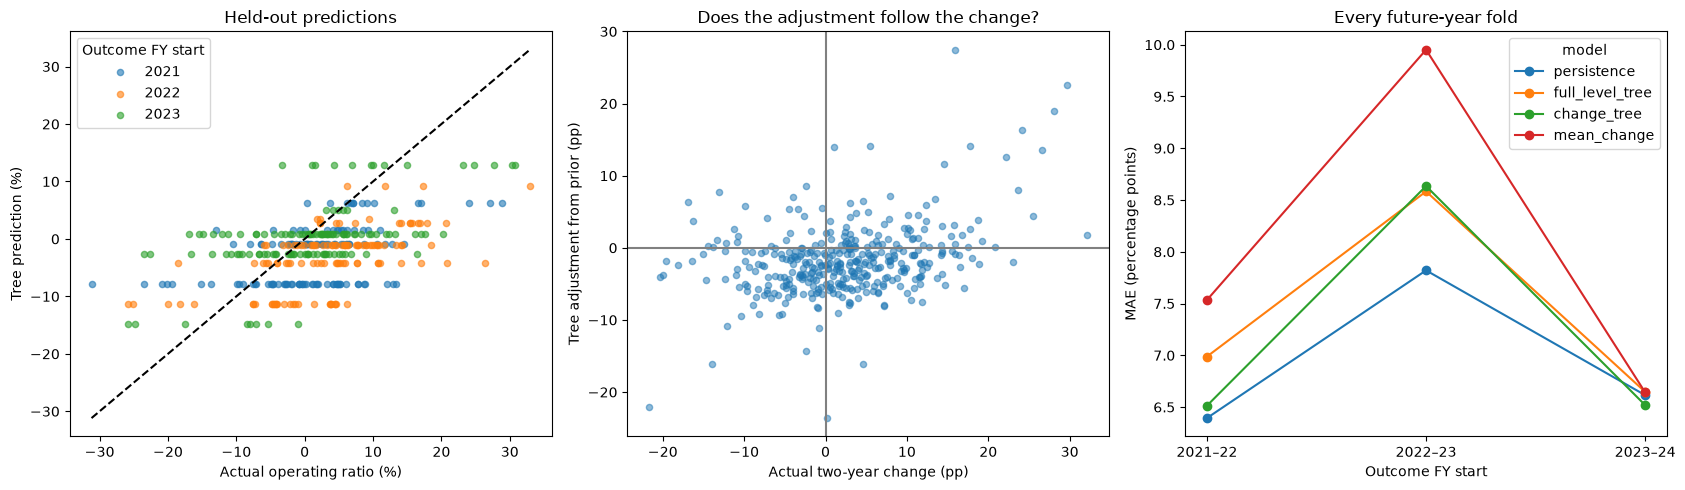

,target,test_year,split,model,n,training_years,MAE,RMSE,R2
6,operating_ratio_pct,2021,test,persistence,124,2019,6.394,8.473,0.080
7,operating_ratio_pct,2021,test,training_mean,124,2019,6.595,9.032,-0.045
8,operating_ratio_pct,2021,test,mean_change,124,2019,7.534,9.782,-0.226
9,operating_ratio_pct,2021,test,full_level_tree,124,2019,6.988,8.924,-0.020
10,operating_ratio_pct,2021,test,fiscal_only_tree,124,2019,6.988,8.924,-0.020
11,operating_ratio_pct,2021,test,change_tree,124,2019,6.513,8.450,0.085
18,operating_ratio_pct,2022,test,persistence,122,2019|2020,7.820,9.994,-0.147
19,operating_ratio_pct,2022,test,training_mean,122,2019|2020,8.197,10.466,-0.258
20,operating_ratio_pct,2022,test,mean_change,122,2019|2020,9.951,12.118,-0.687
21,operating_ratio_pct,2022,test,full_level_tree,122,2019|2020,8.583,10.368,-0.235


,target,test_year,model,MAE,RMSE,R2
21,operating_ratio_pct,2021,change_tree,6.513,8.450,-0.051
22,operating_ratio_pct,2021,mean_change,7.534,9.782,-0.408
23,operating_ratio_pct,2021,persistence,6.394,8.473,-0.057
24,operating_ratio_pct,2022,change_tree,8.635,10.568,-0.580
25,operating_ratio_pct,2022,mean_change,9.951,12.118,-1.078
26,operating_ratio_pct,2022,persistence,7.820,9.994,-0.413
27,operating_ratio_pct,2023,change_tree,6.519,8.626,-0.020
28,operating_ratio_pct,2023,mean_change,6.642,8.615,-0.017
29,operating_ratio_pct,2023,persistence,6.615,8.551,-0.002


CSV unchanged; all original tree predictions reproduced; no original experiment outputs overwritten.


In [7]:
fig, axes=plt.subplots(1,3,figsize=(17,5))
g=base[base.target=='operating_ratio_pct']
for year,h in g.groupby('test_year'):
    axes[0].scatter(h.actual,h.predicted,label=str(year),alpha=.6,s=20)
lo=min(g.actual.min(),g.predicted.min()); hi=max(g.actual.max(),g.predicted.max())
axes[0].plot([lo,hi],[lo,hi],color='black',linestyle='--'); axes[0].legend(title='Outcome FY start')
axes[0].set(xlabel='Actual operating ratio (%)',ylabel='Tree prediction (%)',title='Held-out predictions')
axes[1].scatter(g.change,g.tree_adjustment,alpha=.5,s=20)
axes[1].axhline(0,color='grey'); axes[1].axvline(0,color='grey')
axes[1].set(xlabel='Actual two-year change (pp)',ylabel='Tree adjustment from prior (pp)',title='Does the adjustment follow the change?')
v=fold_metrics[(fold_metrics.target=='operating_ratio_pct') & (fold_metrics.split=='test')]
v.pivot(index='test_year',columns='model',values='MAE')[['persistence','full_level_tree','change_tree','mean_change']].plot(marker='o',ax=axes[2])
axes[2].set(xlabel='Outcome FY start',ylabel='MAE (percentage points)',title='Every future-year fold')
axes[2].set_xticks([2021,2022,2023], ['2021–22','2022–23','2023–24'])
fig.tight_layout(); fig.savefig(OUT/'operating_ratio_diagnosis.png',dpi=170); plt.show(); plt.close(fig)
# R² for changes has a different reference mean than R² for levels; report both explicitly.
change_scores=[]
for (target,year,model),g in pred[pred.model.isin(['persistence','mean_change','change_tree'])].groupby(['target','test_year','model']):
    change_scores.append(dict(target=target,test_year=year,model=model,
        **metrics(g.change,g.predicted-g.prior)))
change_scores=pd.DataFrame(change_scores); change_scores.to_csv(OUT/'change_target_metrics.csv',index=False)
display(fold_metrics[(fold_metrics.split=='test') & (fold_metrics.target=='operating_ratio_pct')].round(3))
display(change_scores[change_scores.target=='operating_ratio_pct'].round(3))
assert hashlib.sha256(SOURCE.read_bytes()).hexdigest()==SOURCE_HASH
print('CSV unchanged; all original tree predictions reproduced; no original experiment outputs overwritten.')


## 7. Effective time coverage
Council rows are not independent disaster histories. Inspect the number of distinct target years and exposure-positive rows in each training and test sample. The primary test exposure years are 2020–21 through 2022–23; this is not a held-out test of the 2019–20 Black Summer year.

In [8]:
coverage_rows=[]
for target,d in cohorts.items():
    for year in sorted(base.loc[base.target==target,'test_year'].unique()):
        for split,frame in [('train',d[d.eligible & (d.target_year<year-1)]),('test',d[d.eligible & (d.target_year==year)])]:
            coverage_rows.append(dict(target=target,test_year=year,split=split,n=len(frame),
                distinct_target_years=frame.target_year.nunique(),
                event_years='|'.join(map(str,sorted(frame.event_year.unique()))),
                target_mean=frame[target+'__future'].mean(),
                change_mean=(frame[target+'__future']-frame[target+'__prior']).mean(),
                bushfire_declared_n=int((frame.bushfire_declared_event_count__event>0).sum()),
                flood_declared_n=int((frame.flood_declared_event_count__event>0).sum()),
                mapped_fire_positive_n=int((frame.fesm_burned_ha__event>0).sum())))
coverage=pd.DataFrame(coverage_rows); coverage.to_csv(OUT/'training_test_coverage.csv',index=False)
display(coverage[coverage.target=='operating_ratio_pct'].round(3))


,target,test_year,split,n,distinct_target_years,event_years,target_mean,change_mean,bushfire_declared_n,flood_declared_n,mapped_fire_positive_n
0,operating_ratio_pct,2021,train,121,1,2018,-0.425,-3.305,19,44,44
1,operating_ratio_pct,2021,test,124,1,2020,1.451,1.962,0,82,31
2,operating_ratio_pct,2022,train,243,2,2018|2019,-1.004,-3.324,66,131,104
3,operating_ratio_pct,2022,test,122,1,2021,3.738,5.403,0,108,33
4,operating_ratio_pct,2023,train,367,3,2018|2019|2020,-0.175,-1.538,66,213,135
5,operating_ratio_pct,2023,test,124,1,2022,1.037,-0.414,19,74,67


# Fiscal prediction failure: evidence-based diagnosis

## Verdict
**NO-GO for escalating this specification to more complex predictive models.** The diagnosis does not establish that fiscal conditions are intrinsically unpredictable. It shows that this small historical panel and shallow tree do not consistently improve on a council's own earlier fiscal value. All original held-out predictions were reproduced, and the source CSV is unchanged.

## What the diagnostics establish

### 1. The tree throws away useful council-specific persistence
A regression tree assigns the same prediction to every council in a leaf. The primary tree produced only four, six and five different predictions in the three held-out years. Its adjustment from each council's prior operating ratio worsened absolute error for **56.8%** of held-out rows and improved it for 43.2%.

A concrete example is **Warren, outcome FY 2022–23**: the pre-event operating ratio was 32.79%, the actual outcome was 32.93%, and the tree predicted 9.19%. Persistence missed by only 0.14 percentage points; the tree missed by 23.74. Group averaging sometimes discards precisely the information that makes persistence strong. This is an observed mechanism, not an argument to remove Warren or increase tree depth until it fits.

### 2. The direction of fiscal change did not transfer across years
For FY 2021–22, the sample's actual mean two-year change was **+1.96 pp**, but the tree's mean adjustment was **−2.27 pp**. For FY 2022–23 the actual change was **+5.40 pp**, but the prediction was **−1.66 pp**, yielding mean underprediction of **7.07 pp**. FY 2023–24 was much closer: mean bias −0.84 pp.

Training MAE was 5.50, 5.40 and 5.39 pp; corresponding future-year MAE was 6.99, 8.58 and 6.65 pp. This documents a training-to-future gap and a missed year-level shift. It is consistent with fitting sample-specific patterns and changing conditions, but the CSV cannot identify which economic or accounting mechanisms caused the shifts. Claims about grants, COVID, rebuilding or other mechanisms would require evidence not present here.

### 3. The supplied disaster features add nothing to these fitted predictions
Removing mapped burned hectares, bushfire declarations and flood declarations produced **identical held-out predictions to numerical precision in all 10 original target/year folds**. Neither the original level trees nor the diagnostic change trees selected exposure variables. This is direct evidence that these inputs made no predictive contribution to the fitted trees; it is not evidence that disasters have no fiscal effect or that all other models must ignore them.

Exposure is also measured coarsely: declaration counts describe onsets rather than local damage intensity; no physical inundation inventory is present; fire mapping has changing size thresholds and unverified polygon vintage. The primary held-out sample has only **19 bushfire-declared rows out of 370**. Its event years are 2020–21 to 2022–23, not a held-out Black Summer test. Those limitations constrain what can be learned but do not, by themselves, prove the reason exposure was unused.

### 4. There are very few independent years, and the forecast spans two years from the baseline
The primary training folds contain 121, 243 and 367 observations, but only **one, two and three outcome years**. Evaluation covers three later outcome years. Repeated councils and shared shocks mean row counts overstate the amount of independent temporal experience.

The requested t−1 → t+1 design spans two financial years from the fiscal baseline. Median absolute observed operating-ratio change over that interval is **5.20 pp**; the 90th percentile is **14.64 pp**. The tree must anticipate large changes while lacking t fiscal information and information about shocks during t+1. Those are genuine information limits of the requested forecast, not permission to add future data.

### 5. The failure is not mainly a missing-value-imputation issue, and is not confined to one outlier
Within the selected primary cohorts, only prior maintenance has missing predictor values: 2, 3 and 4 training values across the folds, and 1, 2 and 2 test values. The selected operating, cash, liquidity, debt, scale and exposure predictors otherwise have no missing values in these cohorts. This makes widespread imputation an implausible main explanation, although excluded outcomes and the missing 2024–25 operating data still limit coverage.

The worst 10% of primary forecasts account for **25.2% of absolute error** and **41.6% of squared error**. Extreme errors matter, especially for RMSE, but most absolute error remains outside that group. No observations were dropped. In all six overlapping hazard-flag subgroups inspected, primary-tree MAE also exceeds persistence MAE; this is not a single subgroup failure. Hazard-negative rows are not certified unexposed controls.

## Did a better target representation fix it?
A diagnostic tree predicting change, then adding it to the council's prior value, improved pooled operating-ratio MAE from **7.40 to 7.22 pp**, but persistence remained better at **6.94 pp**. Corresponding RMSEs are 9.29, 9.26 and 9.03 pp. The change tree beat persistence on MAE in only one of three years. A training-average-change baseline was worse still, at 8.03 pp MAE. Thus group averaging explains part of the problem, but changing the target does not resolve it.

For cash cover, the change tree improves on the original tree (3.94 versus 4.32 months MAE), but still loses to persistence (3.80 months). For maintenance it worsens MAE from 20.90 to 24.63 pp. All comparisons reuse already examined future years and are diagnostics, not independent confirmation.

## What remains unknown and what to do next
The CSV does not provide the operating-ratio numerator and denominator, fiscal release timestamps, grant timing details, or complete physical damage/intensity measurements. We cannot attribute the large fiscal movements to particular economic causes using this source alone. Nor have we tested every possible predictive model or shown an irreducible error bound.

The highest-value next step is a **source/accounting audit of the largest unexpected movements and their publication dates**, if additional sources are authorised, followed by more comparable years and better-timed exposure measurements. Keep persistence as the benchmark. Do not tune on these repeatedly examined years and then call the improvement validation; a revised specification would need a genuinely untouched future evaluation period. Maintain the existing NO-GO for predictive escalation, while retaining descriptive analysis as a viable project output.


In [9]:
REPORT = "# Fiscal prediction failure: evidence-based diagnosis\n\n## Verdict\n**NO-GO for escalating this specification to more complex predictive models.** The diagnosis does not establish that fiscal conditions are intrinsically unpredictable. It shows that this small historical panel and shallow tree do not consistently improve on a council's own earlier fiscal value. All original held-out predictions were reproduced, and the source CSV is unchanged.\n\n## What the diagnostics establish\n\n### 1. The tree throws away useful council-specific persistence\nA regression tree assigns the same prediction to every council in a leaf. The primary tree produced only four, six and five different predictions in the three held-out years. Its adjustment from each council's prior operating ratio worsened absolute error for **56.8%** of held-out rows and improved it for 43.2%.\n\nA concrete example is **Warren, outcome FY 2022–23**: the pre-event operating ratio was 32.79%, the actual outcome was 32.93%, and the tree predicted 9.19%. Persistence missed by only 0.14 percentage points; the tree missed by 23.74. Group averaging sometimes discards precisely the information that makes persistence strong. This is an observed mechanism, not an argument to remove Warren or increase tree depth until it fits.\n\n### 2. The direction of fiscal change did not transfer across years\nFor FY 2021–22, the sample's actual mean two-year change was **+1.96 pp**, but the tree's mean adjustment was **−2.27 pp**. For FY 2022–23 the actual change was **+5.40 pp**, but the prediction was **−1.66 pp**, yielding mean underprediction of **7.07 pp**. FY 2023–24 was much closer: mean bias −0.84 pp.\n\nTraining MAE was 5.50, 5.40 and 5.39 pp; corresponding future-year MAE was 6.99, 8.58 and 6.65 pp. This documents a training-to-future gap and a missed year-level shift. It is consistent with fitting sample-specific patterns and changing conditions, but the CSV cannot identify which economic or accounting mechanisms caused the shifts. Claims about grants, COVID, rebuilding or other mechanisms would require evidence not present here.\n\n### 3. The supplied disaster features add nothing to these fitted predictions\nRemoving mapped burned hectares, bushfire declarations and flood declarations produced **identical held-out predictions to numerical precision in all 10 original target/year folds**. Neither the original level trees nor the diagnostic change trees selected exposure variables. This is direct evidence that these inputs made no predictive contribution to the fitted trees; it is not evidence that disasters have no fiscal effect or that all other models must ignore them.\n\nExposure is also measured coarsely: declaration counts describe onsets rather than local damage intensity; no physical inundation inventory is present; fire mapping has changing size thresholds and unverified polygon vintage. The primary held-out sample has only **19 bushfire-declared rows out of 370**. Its event years are 2020–21 to 2022–23, not a held-out Black Summer test. Those limitations constrain what can be learned but do not, by themselves, prove the reason exposure was unused.\n\n### 4. There are very few independent years, and the forecast spans two years from the baseline\nThe primary training folds contain 121, 243 and 367 observations, but only **one, two and three outcome years**. Evaluation covers three later outcome years. Repeated councils and shared shocks mean row counts overstate the amount of independent temporal experience.\n\nThe requested t−1 → t+1 design spans two financial years from the fiscal baseline. Median absolute observed operating-ratio change over that interval is **5.20 pp**; the 90th percentile is **14.64 pp**. The tree must anticipate large changes while lacking t fiscal information and information about shocks during t+1. Those are genuine information limits of the requested forecast, not permission to add future data.\n\n### 5. The failure is not mainly a missing-value-imputation issue, and is not confined to one outlier\nWithin the selected primary cohorts, only prior maintenance has missing predictor values: 2, 3 and 4 training values across the folds, and 1, 2 and 2 test values. The selected operating, cash, liquidity, debt, scale and exposure predictors otherwise have no missing values in these cohorts. This makes widespread imputation an implausible main explanation, although excluded outcomes and the missing 2024–25 operating data still limit coverage.\n\nThe worst 10% of primary forecasts account for **25.2% of absolute error** and **41.6% of squared error**. Extreme errors matter, especially for RMSE, but most absolute error remains outside that group. No observations were dropped. In all six overlapping hazard-flag subgroups inspected, primary-tree MAE also exceeds persistence MAE; this is not a single subgroup failure. Hazard-negative rows are not certified unexposed controls.\n\n## Did a better target representation fix it?\nA diagnostic tree predicting change, then adding it to the council's prior value, improved pooled operating-ratio MAE from **7.40 to 7.22 pp**, but persistence remained better at **6.94 pp**. Corresponding RMSEs are 9.29, 9.26 and 9.03 pp. The change tree beat persistence on MAE in only one of three years. A training-average-change baseline was worse still, at 8.03 pp MAE. Thus group averaging explains part of the problem, but changing the target does not resolve it.\n\nFor cash cover, the change tree improves on the original tree (3.94 versus 4.32 months MAE), but still loses to persistence (3.80 months). For maintenance it worsens MAE from 20.90 to 24.63 pp. All comparisons reuse already examined future years and are diagnostics, not independent confirmation.\n\n## What remains unknown and what to do next\nThe CSV does not provide the operating-ratio numerator and denominator, fiscal release timestamps, grant timing details, or complete physical damage/intensity measurements. We cannot attribute the large fiscal movements to particular economic causes using this source alone. Nor have we tested every possible predictive model or shown an irreducible error bound.\n\nThe highest-value next step is a **source/accounting audit of the largest unexpected movements and their publication dates**, if additional sources are authorised, followed by more comparable years and better-timed exposure measurements. Keep persistence as the benchmark. Do not tune on these repeatedly examined years and then call the improvement validation; a revised specification would need a genuinely untouched future evaluation period. Maintain the existing NO-GO for predictive escalation, while retaining descriptive analysis as a viable project output.\n"
(OUT/'diagnosis.md').write_text(REPORT)
assert hashlib.sha256(SOURCE.read_bytes()).hexdigest()==SOURCE_HASH
print('Diagnostic report saved; source unchanged.')

Diagnostic report saved; source unchanged.
